In [11]:
import sys
# Absolute path to the cloned repo
repo_path = r'C:\Users\loren\Documents\Repo\InfraPy'

# Add to sys.path
if repo_path not in sys.path:
    sys.path.append(repo_path)

from infrapy.thermoelasticity import lock_in_analysis
import matplotlib.pyplot as plt
import numpy as np
from infrapy import io
from infrapy import utils
from infrapy import thermoelasticity
from infrapy import wti

In [ ]:
# --------------------------
# User-provided data loading
# --------------------------

filenames = r"example_data/test_1/*.hcc" # Path to data

# Read thermal data
data, _ = io.read_ir(filenames)

In [12]:
data = np.load(r'C:\Users\loren\Documents\UNILJ\OutdoorTSA\results\ulfs\preliminary_lab_288hz_111us.npy')

In [13]:
# Convert Kelvin to Celsius
data = utils.kelvin_to_celsius(data)


foi = 288.0# Hz
fs = 1000  # Sampling frequency in Hz

segments = 4
overlap = 0.25

n_samples = data.shape[0]  # assuming first dimension is time
segment_length = int(n_samples / segments)

fft, freq = thermoelasticity.spectral(data, fs, method="fft", segment_length=segment_length, overlap=overlap)
foi_index = np.argmin(np.abs(freq - foi))
amplitude = fft[foi_index]

In [ ]:
# V = np.stack([amplitude1, amplitude2, amplitude3], axis=0)
# reference = []

V = np.stack([amplitude, amplitude, amplitude], axis=0)

In [15]:
# Run MMTRI with history tracking
filtered_map, final_weights, history = wti.process_wti(V,
                                           ground_truth=amplitude,
                                           max_iter=10,
                                           convergence_threshold=0.99)

variance_map, residual_map = wti.wti_diagnostics(V, amplitude)

Converged at iteration 1 (MAC = 1.0000)


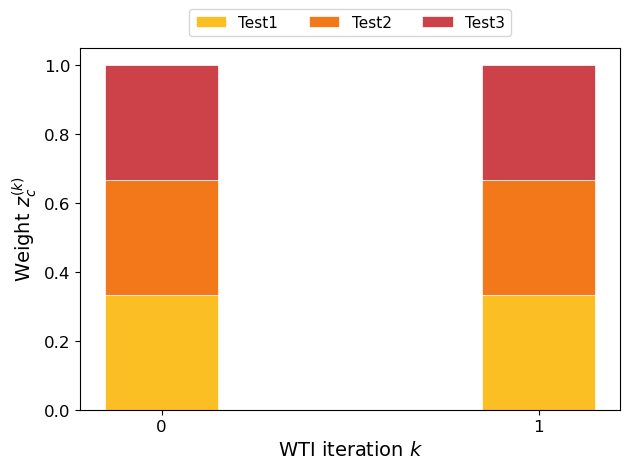

In [ ]:
# Plot Weight evolution
condition_labels = ['Test1', 'Test2', 'Test3']

wti.plot_weight_evolution(history['weights'], condition_labels)